# Fitting on Chip Inductors (1-40 GHz)

This tutorial demonstrates how more complex models can be defined and fit to S-parameter data. We will use data from an electromagnetic simulation of an on-chip inductor (shown below), which is typical in MMICs or RFICs.

The tutorial, along with the data, was provided by one of ParamRF's contributors - thanks @Jormit !

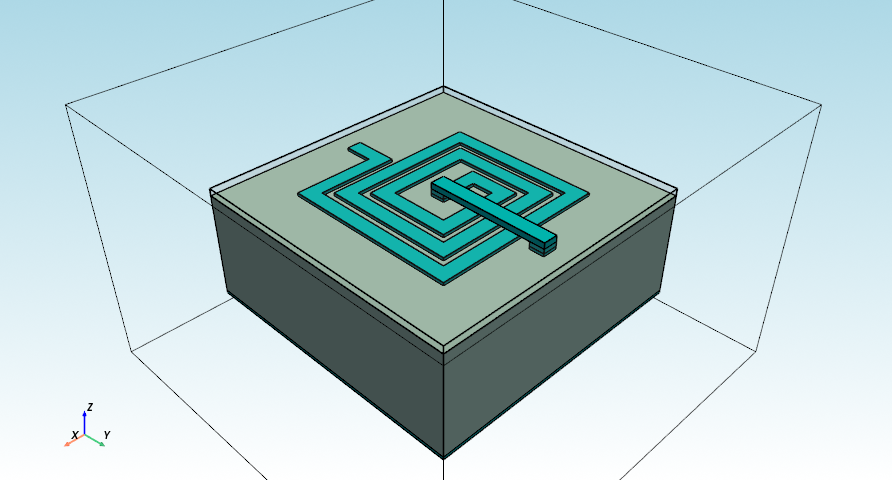


## 1. Setting up the environment

We only need a core packages for this tutorial. Make sure the following all import correctly:

In [2]:
import matplotlib.pyplot as plt     # for plotting
import skrf as rf                   # for touchstone reading
import pmrf as prf                  # ParamRF

## 2. Preparing the data

The on-chip inductor data is available on GitHub. We can pull it dynamically using the following script and plot it:

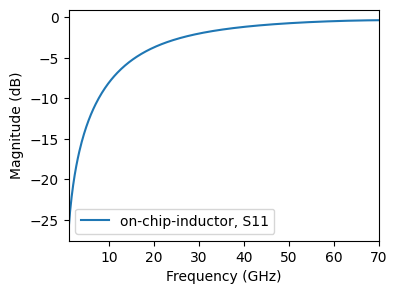

In [3]:
import os
import urllib.request
import skrf as rf
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/gvcallen/paramrf/main/docs/tutorials/data/"
file_name = "on-chip-inductor.s2p"
full_url = base_url + file_name
local_dir = "data"
local_filename = os.path.join(local_dir, file_name)

os.makedirs(local_dir, exist_ok=True)
if not os.path.exists(local_filename):
    print(f"Downloading {file_name} to {local_dir}/...")
    urllib.request.urlretrieve(full_url, local_filename)

# Load the measured data into skrf using the new local path
cem_simulation = rf.Network(local_filename, f_unit='GHz')
fig, ax = plt.subplots(figsize=(4, 3))
cem_simulation.plot_s_db(m=0, n=0, ax=ax)

## 3. Defining the equivalent circuit

To accurately capture the complex parasitic behaviour of this model, we will utilize the equivalent circuit outlined in the paper:
_"N-π Equivalent Circuit for Si CMOS on-Chip Inductor Modeling"_ [IEEE Link](https://ieeexplore.ieee.org/document/4534622). 

The equivalent circuit is built from repeated π sections, where each section models one portion of the spiral trace and its surrounding parasitics. Using multiple sections improves accuracy at higher frequencies, where the distributed nature of the structure becomes significant.

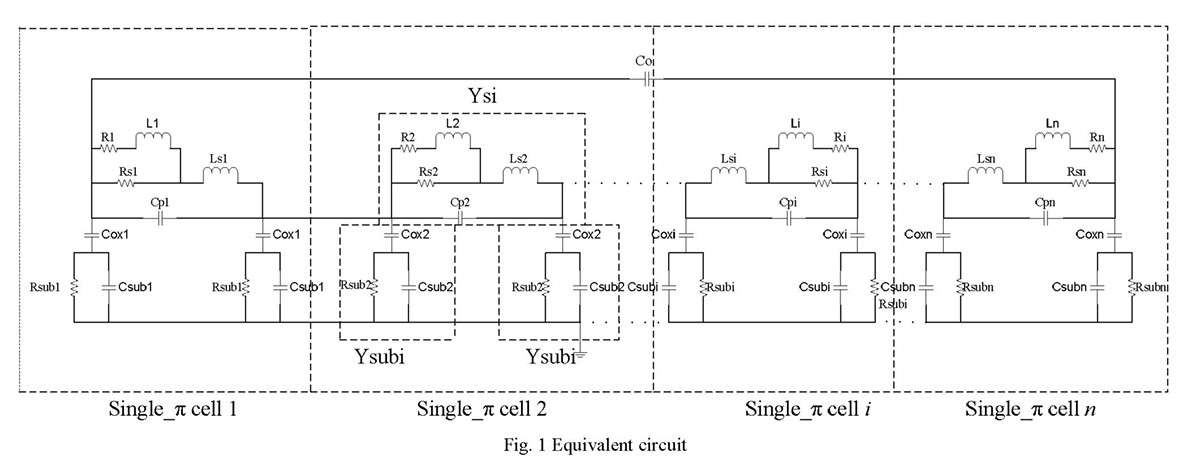

The model is defined in two stages.

First, we define a single π cell according to the schematic above. Here we use a functional approach to define the model, though we could have also defined a custom ParamRF model by inheriting from the `pmrf.Model` class, which is more a slightly more powerful approach, and means we don't have to specify names to keep track of our parameters.

Each passive element is then instantiated individually, for example `L1_model = Inductor(L=L, name="L")`, and the resultant topology is then defined as a list of node connections to pass to `pmrf.models.Circuit`. This declarative connection syntax makes the mapping between schematic and code straightforward to verify.

In [4]:
from pmrf.models import Inductor, Capacitor, Resistor, Port, Ground, Circuit

def single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, **kwargs):
    L1_model = Inductor(L=L, name="L")
    Ls1_model = Inductor(L=Ls, name="Ls")

    Cp1_model = Capacitor(C=Cp, name="Cp")
    Cox1_model = Capacitor(C=Cox1, name="Cox1")
    Cox2_model = Capacitor(C=Cox2, name="Cox2")

    Csub1_model = Capacitor(C=Csub1, name="Csub1")
    Csub2_model = Capacitor(C=Csub2, name="Csub2")

    R1_model = Resistor(R=R, name="R")
    Rs1_model = Resistor(R=Rs, name="Rs")
    Rsub1_model = Resistor(R=Rsub1, name="Rsub1")
    Rsub2_model = Resistor(R=Rsub2, name="Rsub2")

    port1, port2 = Port(), Port()
    ground = Ground()

    connections = [
        [(port1, 0), (Cox1_model, 1), (Cp1_model, 0), (R1_model, 0), (Rs1_model, 0)],
        [(R1_model, 1), (L1_model, 0)],
        [(L1_model, 1), (Rs1_model, 1), (Ls1_model, 0)],
        [(port2, 0), (Cox2_model, 1), (Cp1_model, 1), (Ls1_model, 1)],
        [(Cox1_model, 0), (Rsub1_model, 1), (Csub1_model, 1)],
        [(Cox2_model, 0), (Rsub2_model, 1), (Csub2_model, 1)],
        [
            (ground, 0),
            (Csub1_model, 0),
            (Csub2_model, 0),
            (Rsub1_model, 0),
            (Rsub2_model, 0),
        ],
    ]
    return Circuit(connections, **kwargs)

Next, we re-use the above single-cell definitions inside a loop to build an N-section cascade. Each cell is assigned a unique name (e.g. cell0, cell1) so its parameters can be tracked and inspected independently after fitting. An input-output capacitor `C0` is then added in parallel across the full cascade to account for direct port-to-port coupling, completing the model.

In [5]:
from pmrf.models import Cascade

def multi_pi_cell(num, R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, C0):
    if num <= 1:
        return single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2)

    models = []
    for i in range(num):
        models.append(
            single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, name=f"cell{i}")
        )

    port1, port2 = Port(), Port()
    cascade = Cascade(models)
    C0_model = Capacitor(C=C0)

    connections = [
        [(port1, 0), (cascade, 0), (C0_model, 0)],
        [(port2, 0), (cascade, 1), (C0_model, 1)],
    ]
    return Circuit(connections)


## 4. Specifying bounds and running the fit
With the circuit topology defined, the next step is to extract parameters via optimisation. The `pmrf.Bounded` wrapper tells the optimizer the physically reasonable range for each parameter, and also allows a starting value and a scale factor that helps numerically condition the problem. Choosing sensible bounds is important: too narrow and the optimizer may miss the true solution; too wide and convergence becomes slow and unreliable.

In [6]:
import pmrf as prf

# Define model (N-Pi Equivalent Circuit for Si CMOS on-Chip Inductor Modeling)
inductor_model = multi_pi_cell(
    num=2,
    R=prf.Bounded(0.0, 1000.0, value=0.0, scale=1.0),
    L=prf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Rs=prf.Bounded(0.0, 1000.0, value=0.0, scale=1.0),
    Ls=prf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Cp=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
    Cox1=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
    Cox2=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
    Rsub1=prf.Bounded(0.0, 1000.0, value=0.0, scale=1.0),
    Csub1=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
    Rsub2=prf.Bounded(0.0, 1000.0, value=0.0, scale=1.0),
    Csub2=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
    C0=prf.Bounded(0.0, 5.0, value=0.0, scale=1e-12),
)

Next, we run the actual fit. The `pmrf.fitting.fit` uses SciPy's optimizer by default, minimizing the difference between the modeled and measured S-parameters across all frequencies simultaneously. Convergence typically takes a few hundred iterations. Once complete, `fit_results` holds both the optimized parameter values and the fitted network, ready for post-processing.

In [7]:
fit_results = prf.fitting.fit(inductor_model, cem_simulation)

import pprint
print("Final Fitted Parameters:")
pprint.pprint(fit_results.model.named_params())

SciPy (default):   0%|          | 0/1024 [00:00<?, ?it/s]

Final Fitted Parameters:
{'cell0_Cox1.C': 1.1672124110629759e-14,
 'cell0_Cox2.C': 6.586434580639969e-15,
 'cell0_Cp.C': 0.0,
 'cell0_Csub1.C': 1.8250456507105948e-20,
 'cell0_Csub2.C': 2.71153948824812e-21,
 'cell0_L.L': 4.988582860130512e-10,
 'cell0_Ls.L': 2.0974832409803188e-10,
 'cell0_R.R': 1.4802627003148833e-06,
 'cell0_Rs.R': 1.475935233531987,
 'cell0_Rsub1.R': 0.10336179992923777,
 'cell0_Rsub2.R': 0.0805487540605648,
 'cell1_Cox1.C': 6.586434210719848e-15,
 'cell1_Cox2.C': 1.68093233047302e-14,
 'cell1_Cp.C': 6.6730595769363866e-15,
 'cell1_Csub1.C': 2.710800670393846e-21,
 'cell1_Csub2.C': 0.0,
 'cell1_L.L': 4.974472649850379e-10,
 'cell1_Ls.L': 5.584225069200323e-10,
 'cell1_R.R': 2.581314295817524e-06,
 'cell1_Rs.R': 2.088122349296973,
 'cell1_Rsub1.R': 0.08054875371962371,
 'cell1_Rsub2.R': 0.107037081751213,
 'circuit[2].C': 2.661689190957073e-16}


## 5. Analyzing the results
### S-Parameters
Now that the fit is converged, we can plot the fitted model's S-parameters against the CEM simulation. We first plot the general fit results, and then convert our models to scikit-rf networks in order to use its extensive plotting tools.

Text(0.5, 1.0, 'Smith Chart - Model vs Simulated')

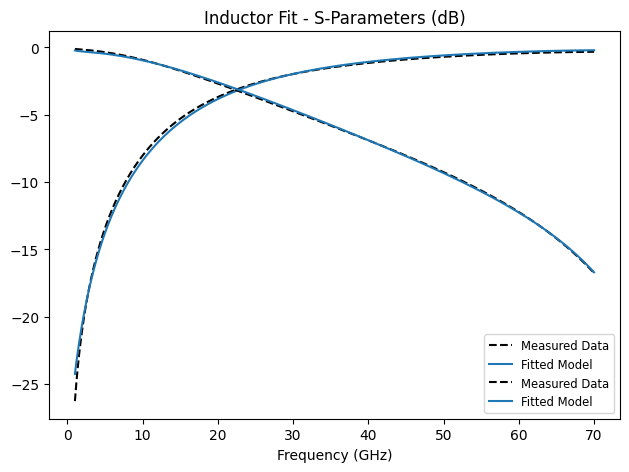

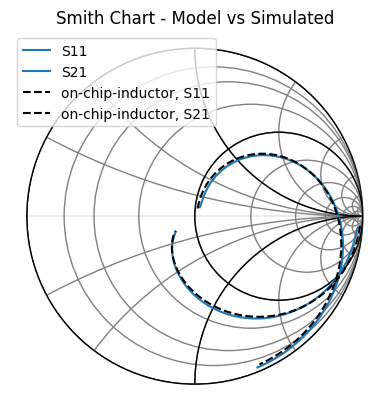

In [9]:
import matplotlib.pyplot as plt

# Plot the S-parameters in dB at the fit frequency
fig1, ax1 = plt.subplots()
fit_results.plot_s_db(m=0, n=0, ax=ax1)
fit_results.plot_s_db(m=1, n=0, ax=ax1)
ax1.set_title("Inductor Fit - S-Parameters (dB)")

# Plot the S-parameters on the smith chart at a custom frequency
fig2, ax2 = plt.subplots()
freq = prf.Frequency(1, 70, 1001, "GHz")
skrf_model = fit_results.model.to_skrf(frequency=freq)
skrf_model.plot_s_smith(m=0, n=0, ax=ax2, color="tab:blue")
skrf_model.plot_s_smith(m=1, n=0, ax=ax2, color="tab:blue")
cem_simulation.plot_s_smith(m=0, n=0, ax=ax2, color="black", linestyle="--")
cem_simulation.plot_s_smith(m=1, n=0, ax=ax2, color="black", linestyle="--")
ax2.set_title("Smith Chart - Model vs Simulated")

It is clear that the model agrees extremely well with the true value, demonstrating correctness in the both model as well as our choice of solver.

### Inductance and Q Factor
Finally, we print out the Inductance and Q-factor by defining custom plots directly using matplotlib. We make use of ParamRF's built in conversions in `pmrf.rf`, as well as JAX's `jnp.real` and `jnp.imag` NumPy-like functions.

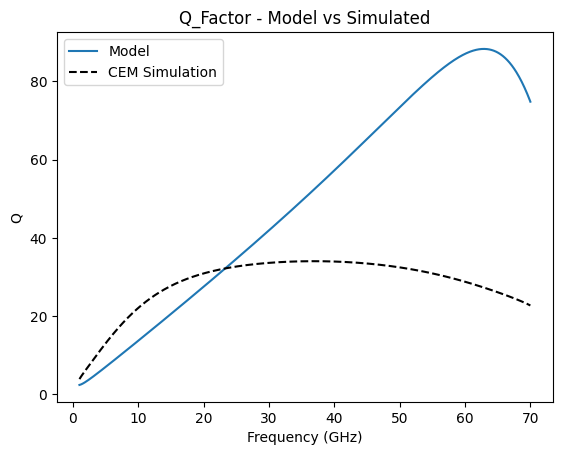

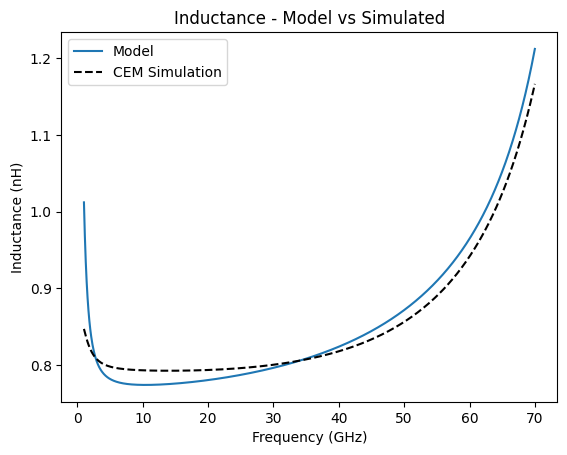

In [10]:
import jax.numpy as jnp

freq = prf.Frequency(1, 70, 1001, "GHz")
model = fit_results.model.s(freq)

def q_factor(s_params):
    y = prf.rf.s2y(s_params)
    z = 1 / y[:, 0, 1]
    z_real = jnp.real(z)
    z_imag = jnp.imag(z)
    return z_imag / z_real

def inductance(s_params, freqs):
    y = prf.rf.s2y(s_params)
    z = -1 / y[:, 0, 1]
    z_imag = jnp.imag(z)
    L = z_imag / (freqs * 2 * jnp.pi)
    return L * 1e9

fig1, ax1 = plt.subplots()
ax1.plot(freq.f / 1e9, q_factor(model), color="tab:blue", label='Model')
ax1.plot(cem_simulation.f / 1e9, q_factor(cem_simulation.s), color="black", linestyle="--", label='CEM Simulation')
ax1.set_title("Q_Factor - Model vs Simulated")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Q")

fig1, ax2 = plt.subplots()
ax2.plot(freq.f / 1e9, inductance(model, freq.f), color="tab:blue", label='Model')
ax2.plot(cem_simulation.f / 1e9, inductance(cem_simulation.s, cem_simulation.f), color="black", linestyle="--", label='CEM Simulation')
ax2.set_title("Inductance - Model vs Simulated")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Inductance (nH)")

ax1.legend()
ax2.legend()